# BitLocker Status Analysis

This notebook provides interactive analysis and visualization of diagnostic data collected by `Get-BitLockerStatus.ps1`.

## Setup

1. Set `DATA_DIR` below to point to your collected logs folder (e.g., `BitLockerStatus-DD-MM-YYYY-HH-MM`).
2. Run all cells to generate the analysis report.

## Contents

- [Configuration](#Configuration)
- [BitLocker Volume Status](#BitLocker-Volume-Status)
- [MDM Policy Analysis](#MDM-Policy-Analysis)
- [Event Log Analysis](#Event-Log-Analysis)
- [Errors & Warnings](#Errors-&-Warnings)
- [Summary](#Summary)

## Configuration

In [1]:
# Import required libraries
import os
import re
from pathlib import Path
from datetime import datetime
from typing import Optional

import pandas as pd
from lxml import etree

# Optional imports - graceful degradation if not available
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOTTING = True
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = [12, 6]
except ImportError:
    HAS_PLOTTING = False
    print("Warning: matplotlib/seaborn not available. Visualizations will be skipped.")

try:
    from Evtx.Evtx import Evtx
    from Evtx.Views import evtx_file_xml_view
    HAS_EVTX = True
except ImportError:
    HAS_EVTX = False
    print("Warning: python-evtx not available. Event log parsing will be skipped.")

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Set the path to your BitLocker diagnostic data folder
# Update this to point to the folder created by Get-BitLockerStatus.ps1
DATA_DIR = Path(r"C:\Temp\tsscat\Get-BitLockerStatus\ExampleData")

# Validate the data directory exists
if not DATA_DIR.exists():
    print(f"ERROR: Data directory not found: {DATA_DIR}")
    print("Please update DATA_DIR to point to your BitLocker diagnostic folder.")
else:
    print(f"Data directory: {DATA_DIR.resolve()}")
    print(f"\nAvailable files:")
    for f in sorted(DATA_DIR.rglob("*")):
        if f.is_file():
            size_kb = f.stat().st_size / 1024
            print(f"  {f.relative_to(DATA_DIR)} ({size_kb:.1f} KB)")

Data directory: C:\Temp\tsscat\Get-BitLockerStatus\ExampleData

Available files:
  FVE_Policies.reg (2.6 KB)
  FVE_Policies_export.txt (0.1 KB)
  Get-BitLockerStatus.log (2.3 KB)
  Get-BitLockerVolume.txt (0.5 KB)
  Get-TPM.txt (0.7 KB)
  Manage-BDE_Status.txt (0.6 KB)
  MDMDiagReport.html (638.0 KB)
  MDMDiagReport.xml (5163.7 KB)
  Microsoft-Windows-BitLocker-API_Management.evtx (1092.0 KB)
  Reagentc.txt (0.5 KB)
  system.evtx (32836.0 KB)


## BitLocker Volume Status

Parse and display the output from `Get-BitLockerVolume`.

In [3]:
def parse_bitlocker_volume(file_path: Path) -> Optional[pd.DataFrame]:
    """
    Parse Get-BitLockerVolume.txt output into a DataFrame.
    
    The output format is a series of key-value pairs for each volume,
    separated by blank lines.
    """
    if not file_path.exists():
        return None
    
    content = file_path.read_text(encoding='utf-8', errors='ignore')
    
    # Split into volume blocks (separated by double newlines or volume headers)
    volumes = []
    current_volume = {}
    
    for line in content.splitlines():
        line = line.strip()
        
        # Skip empty lines but use them to separate volumes
        if not line:
            if current_volume:
                volumes.append(current_volume)
                current_volume = {}
            continue
        
        # Parse key : value pairs
        if ':' in line:
            # Handle multi-colon lines (e.g., timestamps)
            parts = line.split(':', 1)
            if len(parts) == 2:
                key = parts[0].strip()
                value = parts[1].strip()
                
                # Handle special cases where value contains more colons
                if key and value:
                    current_volume[key] = value
                elif key and not value:
                    # Value might be on next lines (like KeyProtector)
                    current_volume[key] = ""
    
    # Don't forget the last volume
    if current_volume:
        volumes.append(current_volume)
    
    if not volumes:
        return None
    
    return pd.DataFrame(volumes)

In [4]:
# Parse BitLocker volume status
bitlocker_file = DATA_DIR / "Get-BitLockerVolume.txt"
bitlocker_df = parse_bitlocker_volume(bitlocker_file)

if bitlocker_df is not None:
    print("BitLocker Volume Status")
    print("=" * 50)
    display(bitlocker_df)
    
    # Show key columns if they exist
    key_cols = ['MountPoint', 'VolumeStatus', 'ProtectionStatus', 'EncryptionMethod', 'EncryptionPercentage']
    available_cols = [c for c in key_cols if c in bitlocker_df.columns]
    if available_cols:
        print("\nKey Status Summary:")
        display(bitlocker_df[available_cols])
else:
    print(f"BitLocker volume file not found: {bitlocker_file}")
    print("This file is generated when Get-BitLockerStatus.ps1 runs successfully.")

BitLocker Volume Status


,ComputerName,MountPoint,EncryptionMethod,EncryptionMethodFlags,AutoUnlockEnabled,AutoUnlockKeyStored,MetadataVersion,VolumeStatus,ProtectionStatus,LockStatus,EncryptionPercentage,WipePercentage,VolumeType,CapacityGB,KeyProtector
0,DESKTOP-KIJL01G,C:,XtsAes128,None,,False,2,FullyEncrypted,On,Unlocked,100,0,OperatingSystem,930.3773,"{Tpm, RecoveryPassword}"



Key Status Summary:


,MountPoint,VolumeStatus,ProtectionStatus,EncryptionMethod,EncryptionPercentage
0,C:,FullyEncrypted,On,XtsAes128,100


## MDM Policy Analysis

Parse BitLocker MDM configuration from the MDM diagnostic report.

In [5]:
def parse_mdm_bitlocker_xml(file_path: Path) -> Optional[pd.DataFrame]:
    """
    Parse BitlockerMDM.xml or extract BitLocker areas from MDMDiagReport.xml.
    
    Returns a DataFrame with policy settings.
    """
    if not file_path.exists():
        return None
    
    try:
        tree = etree.parse(str(file_path))
        root = tree.getroot()
        
        policies = []
        
        # Look for BitLocker policy areas in MDMDiagReport.xml format
        # Search for PolicyAreaName containing 'BitLocker'
        for area in root.iter():
            if area.tag == 'PolicyAreaName' and 'BitLocker' in (area.text or ''):
                # Get the parent element which should contain the policy details
                parent = area.getparent()
                if parent is not None:
                    policy_data = {'AreaName': area.text}
                    for child in parent:
                        if child.text and child.tag != 'PolicyAreaName':
                            policy_data[child.tag] = child.text
                    if len(policy_data) > 1:
                        policies.append(policy_data)
        
        # Also look for CSP-style BitLocker settings
        for elem in root.iter():
            elem_text = elem.text or ''
            if 'BitLocker' in elem.tag or 'BitLocker' in elem_text:
                if elem.tag not in ['PolicyAreaName']:
                    policy_entry = {
                        'Setting': elem.tag,
                        'Value': elem_text[:200] if elem_text else 'N/A',
                        'Path': '/'.join([p.tag for p in elem.iterancestors()][:3][::-1])
                    }
                    # Avoid duplicates
                    if policy_entry not in policies:
                        policies.append(policy_entry)
        
        if policies:
            return pd.DataFrame(policies)
        return None
        
    except etree.XMLSyntaxError as e:
        print(f"XML parsing error: {e}")
        return None

In [6]:
def extract_bitlocker_csp_policies(file_path: Path) -> Optional[pd.DataFrame]:
    """
    Extract BitLocker CSP policies from MDMDiagReport.xml.
    
    Looks for specific BitLocker configuration nodes in the MDM report.
    """
    if not file_path.exists():
        return None
    
    try:
        tree = etree.parse(str(file_path))
        root = tree.getroot()
        
        # Known BitLocker policy settings to look for
        bitlocker_settings = [
            'RequireDeviceEncryption',
            'AllowWarningForOtherDiskEncryption',
            'EncryptionMethodByDriveType',
            'SystemDrivesRequireStartupAuthentication',
            'SystemDrivesMinimumPINLength',
            'SystemDrivesRecoveryMessage',
            'SystemDrivesRecoveryOptions',
            'FixedDrivesRecoveryOptions',
            'FixedDrivesRequireEncryption',
            'RemovableDrivesRequireEncryption',
        ]
        
        results = []
        
        # Search for elements containing BitLocker settings
        for setting in bitlocker_settings:
            for elem in root.iter():
                if setting in elem.tag or (elem.text and setting in elem.text):
                    results.append({
                        'Setting': setting,
                        'Element': elem.tag,
                        'Value': (elem.text or '')[:100]
                    })
        
        # Find configuration areas with "BitLocker" in policy area name
        for area in root.iter('PolicyAreaName'):
            if area.text and 'BitLocker' in area.text:
                parent = area.getparent()
                if parent is not None:
                    for child in parent:
                        if child.tag != 'PolicyAreaName' and child.text:
                            results.append({
                                'Setting': child.tag,
                                'Element': 'PolicyArea',
                                'Value': child.text[:100]
                            })
        
        if results:
            df = pd.DataFrame(results).drop_duplicates()
            return df
        return None
        
    except Exception as e:
        print(f"Error parsing MDM report: {e}")
        return None

In [7]:
# Try to find MDM BitLocker configuration
mdm_files = [
    DATA_DIR / "MDM" / "BitlockerMDM.xml",  # Extracted by Get-BitLockerStatus.ps1
    DATA_DIR / "BitlockerMDM.xml",           # Alternative location
    DATA_DIR / "MDMDiagReport.xml",          # Full MDM report
]

mdm_df = None
mdm_source = None

for mdm_file in mdm_files:
    if mdm_file.exists():
        print(f"Found MDM data: {mdm_file}")
        mdm_source = mdm_file
        
        # Try specialized extraction first
        mdm_df = extract_bitlocker_csp_policies(mdm_file)
        if mdm_df is None:
            mdm_df = parse_mdm_bitlocker_xml(mdm_file)
        
        if mdm_df is not None:
            break

if mdm_df is not None:
    print(f"\nBitLocker MDM Policy Settings (from {mdm_source.name})")
    print("=" * 60)
    display(mdm_df)
else:
    print("No MDM BitLocker configuration found.")
    print("MDM data is only present if Get-BitLockerStatus.ps1 was run with -MDM flag.")

Found MDM data: C:\Temp\tsscat\Get-BitLockerStatus\ExampleData\MDMDiagReport.xml



BitLocker MDM Policy Settings (from MDMDiagReport.xml)


,Setting,Element,Value
0,RequireDeviceEncryption,RequireDeviceEncryption,1
2,RequireDeviceEncryption,RequireDeviceEncryption_ProviderSet,1
3,RequireDeviceEncryption,RequireDeviceEncryption_WinningProvider,D35A8C7B-9941-4704-986E-F9C7FEF69668
4,RequireDeviceEncryption,Metadata2,./Device/Vendor/MSFT/BitLocker/RequireDeviceEncryption
5,RequireDeviceEncryption,PolicyName,RequireDeviceEncryption
...,...,...,...
125,SystemDrivesEncryptionType_ADMXInstanceData,PolicyArea,Software\Microsoft\PolicyManager\providers\D35A8C7B-9941-4704-986E-F9C7FEF69668\default\Device\BitLo
126,SystemDrivesEnhancedPIN_ADMXInstanceData,PolicyArea,Software\Microsoft\PolicyManager\providers\D35A8C7B-9941-4704-986E-F9C7FEF69668\default\Device\BitLo
127,SystemDrivesMinimumPINLength_ADMXInstanceData,PolicyArea,Software\Microsoft\PolicyManager\providers\D35A8C7B-9941-4704-986E-F9C7FEF69668\default\Device\BitLo
128,SystemDrivesRecoveryOptions_ADMXInstanceData,PolicyArea,Software\Microsoft\PolicyManager\providers\D35A8C7B-9941-4704-986E-F9C7FEF69668\default\Device\BitLo


## Event Log Analysis

Parse Windows Event Logs (.evtx) for BitLocker-related events.

In [8]:
def parse_evtx_file(file_path: Path, max_events: int = 1000) -> Optional[pd.DataFrame]:
    """
    Parse a Windows Event Log (.evtx) file into a DataFrame.
    
    Args:
        file_path: Path to the .evtx file
        max_events: Maximum number of events to parse (for performance)
    
    Returns:
        DataFrame with event data or None if parsing fails
    """
    if not HAS_EVTX:
        print("python-evtx library not available. Install with: pip install python-evtx")
        return None
    
    if not file_path.exists():
        return None
    
    events = []
    
    try:
        with Evtx(str(file_path)) as evtx:
            for i, record in enumerate(evtx.records()):
                if i >= max_events:
                    break
                
                try:
                    xml_str = record.xml()
                    root = etree.fromstring(xml_str.encode('utf-8'))
                    
                    # Extract common event fields
                    ns = {'e': 'http://schemas.microsoft.com/win/2004/08/events/event'}
                    
                    system = root.find('e:System', ns)
                    event_data = root.find('e:EventData', ns)
                    
                    event = {
                        'EventID': system.findtext('e:EventID', default='', namespaces=ns),
                        'TimeCreated': '',
                        'Level': system.findtext('e:Level', default='', namespaces=ns),
                        'Provider': '',
                        'Message': ''
                    }
                    
                    # Get timestamp
                    time_elem = system.find('e:TimeCreated', ns)
                    if time_elem is not None:
                        event['TimeCreated'] = time_elem.get('SystemTime', '')
                    
                    # Get provider
                    provider_elem = system.find('e:Provider', ns)
                    if provider_elem is not None:
                        event['Provider'] = provider_elem.get('Name', '')
                    
                    # Get event data/message
                    if event_data is not None:
                        data_items = []
                        for data in event_data:
                            name = data.get('Name', '')
                            value = data.text or ''
                            if name:
                                data_items.append(f"{name}={value}")
                            elif value:
                                data_items.append(value)
                        event['Message'] = '; '.join(data_items)[:500]
                    
                    events.append(event)
                    
                except Exception as e:
                    continue
        
        if events:
            df = pd.DataFrame(events)
            # Convert timestamp to datetime
            if 'TimeCreated' in df.columns:
                df['TimeCreated'] = pd.to_datetime(df['TimeCreated'], errors='coerce')
                df = df.sort_values('TimeCreated', ascending=False)
            return df
        
        return None
        
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

In [9]:
# Parse BitLocker API event log
bitlocker_evtx = DATA_DIR / "Microsoft-Windows-BitLocker-API_Management.evtx"
bitlocker_events_df = parse_evtx_file(bitlocker_evtx)

if bitlocker_events_df is not None:
    print(f"BitLocker API Events ({len(bitlocker_events_df)} events)")
    print("=" * 60)
    display(bitlocker_events_df.head(20))
    
    # Show event ID distribution
    print("\nEvent ID Distribution:")
    display(bitlocker_events_df['EventID'].value_counts().head(10))
else:
    print(f"BitLocker event log not found: {bitlocker_evtx}")

BitLocker API Events (122 events)


,EventID,TimeCreated,Level,Provider,Message
121,868,2025-11-16 12:25:57.059954+00:00,3,Microsoft-Windows-BitLocker-API,ErrorCode=-2147012889
120,875,2025-11-16 12:25:57.059944+00:00,2,Microsoft-Windows-BitLocker-API,ErrorCode=-2145845248; HttpStatusCode=0; RetryRequest=False; DidSetRetryHint=False; RetryHint=0
119,840,2025-10-15 19:00:15.107615+00:00,4,Microsoft-Windows-BitLocker-API,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; BinaryDataSize=32; BinaryData=U+zt0uHi8BhYrrDdyT93HGLFtA9XH0d03xpeQlhdSjk=
118,890,2025-10-15 19:00:15.068258+00:00,4,Microsoft-Windows-BitLocker-API,
117,793,2025-10-15 19:00:15.068186+00:00,3,Microsoft-Windows-BitLocker-API,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:
116,892,2025-10-15 19:00:15.067858+00:00,4,Microsoft-Windows-BitLocker-API,"PCRBitmap=2176; PCRBitmapSource=3; PCRValuesSize=72; PCRValues=CwAgAByUPOAv599q26zhtXc5j35Xr7yDlmog7NHX77jSSav/CwAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA; FilteredLog={""DigestAlgID"":11,""DigestSize"":32,""SupportedDigestAlgIDBitmap"":3,""Events"":[{""Pcr"":7,""EventType"":""EV_EFI_VARIABLE_DRIVER_CONFIG"",""EventDataPrintable"":""a.S.e.c.u.r.e.B.o.o.t."",""SecureBootEnabled"":1,""Digests"":[{""Alg"":""SHA1"",""EventDigest"":""d4fdd1f14d4041494deb8fc990c45343d2277d08""},{""Alg"":""SHA256"",""EventDigest"":""ccfc4bb32888a345b"
115,840,2025-10-15 19:00:13.156853+00:00,4,Microsoft-Windows-BitLocker-API,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; BinaryDataSize=32; BinaryData=U+zt0uHi8BhYrrDdyT93HGLFtA9XH0d03xpeQlhdSjk=
114,890,2025-10-15 19:00:13.113871+00:00,4,Microsoft-Windows-BitLocker-API,
113,793,2025-10-15 19:00:13.113804+00:00,3,Microsoft-Windows-BitLocker-API,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:
112,892,2025-10-15 19:00:13.113508+00:00,4,Microsoft-Windows-BitLocker-API,"PCRBitmap=2176; PCRBitmapSource=3; PCRValuesSize=72; PCRValues=CwAgAPfj/QRNZbmBRNHfH/q/6YjY6J/cFIkSDFian/2zCh36CwAgAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA; FilteredLog={""DigestAlgID"":11,""DigestSize"":32,""SupportedDigestAlgIDBitmap"":3,""Events"":[{""Pcr"":7,""EventType"":""EV_EFI_VARIABLE_DRIVER_CONFIG"",""EventDataPrintable"":""a.S.e.c.u.r.e.B.o.o.t."",""SecureBootEnabled"":1,""Digests"":[{""Alg"":""SHA1"",""EventDigest"":""d4fdd1f14d4041494deb8fc990c45343d2277d08""},{""Alg"":""SHA256"",""EventDigest"":""ccfc4bb32888a345b"



Event ID Distribution:


EventID
793    28
792    25
840    20
817    17
890    11
892    11
779     3
875     2
868     2
812     2
Name: count, dtype: int64

In [10]:
# Parse System event log (for TPM and boot-related events)
system_evtx = DATA_DIR / "system.evtx"
system_events_df = parse_evtx_file(system_evtx, max_events=500)

if system_events_df is not None:
    # Filter for potentially relevant events (TPM, BitLocker, boot)
    relevant_providers = ['Microsoft-Windows-TPM', 'Microsoft-Windows-BitLocker', 'Microsoft-Windows-Kernel']
    
    # Show sample of system events
    print(f"System Events ({len(system_events_df)} events parsed)")
    print("=" * 60)
    display(system_events_df.head(10))
    
    # Provider distribution
    print("\nTop Event Providers:")
    display(system_events_df['Provider'].value_counts().head(10))
else:
    print(f"System event log not found: {system_evtx}")

System Events (500 events parsed)


,EventID,TimeCreated,Level,Provider,Message
499,10016,2025-06-14 00:31:25.580679+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
498,10016,2025-06-14 00:31:25.574680+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
497,10016,2025-06-14 00:31:25.570679+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
496,10016,2025-06-14 00:31:25.565674+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
495,10016,2025-06-14 00:31:25.560675+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
494,10016,2025-06-14 00:31:25.555674+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
493,10016,2025-06-14 00:31:25.551262+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
492,10016,2025-06-14 00:31:25.544262+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; param4={C4E82530-3B6E-4F6A-8E99-07426B47D292}; param5={F9717507-6651-4EDB-BFF7-AE615179BCCF}; param6=AzureAD; param7=KevinKaminski; param8=S-1-12-1-614343042-1134429426-2202095523-3655237456; param9=LocalHost (Using LRPC); param10=Unavailable; param11=S-1-15-2-1014435658-1286188694-3576656726-1801626567-789551613-3065732721-1059358417
491,10016,2025-06-14 00:31:25.538790+00:00,3,Microsoft-Windows-DistributedCOM,param1=application-specific; param2=Local; param3=Activation; 


Top Event Providers:


Provider
Microsoft-Windows-DistributedCOM    500
Name: count, dtype: int64

C:\Users\KevinKaminski\AppData\Local\Temp\ipykernel_35400\2786159310.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  events_with_time['Hour'] = events_with_time['TimeCreated'].dt.floor('H')


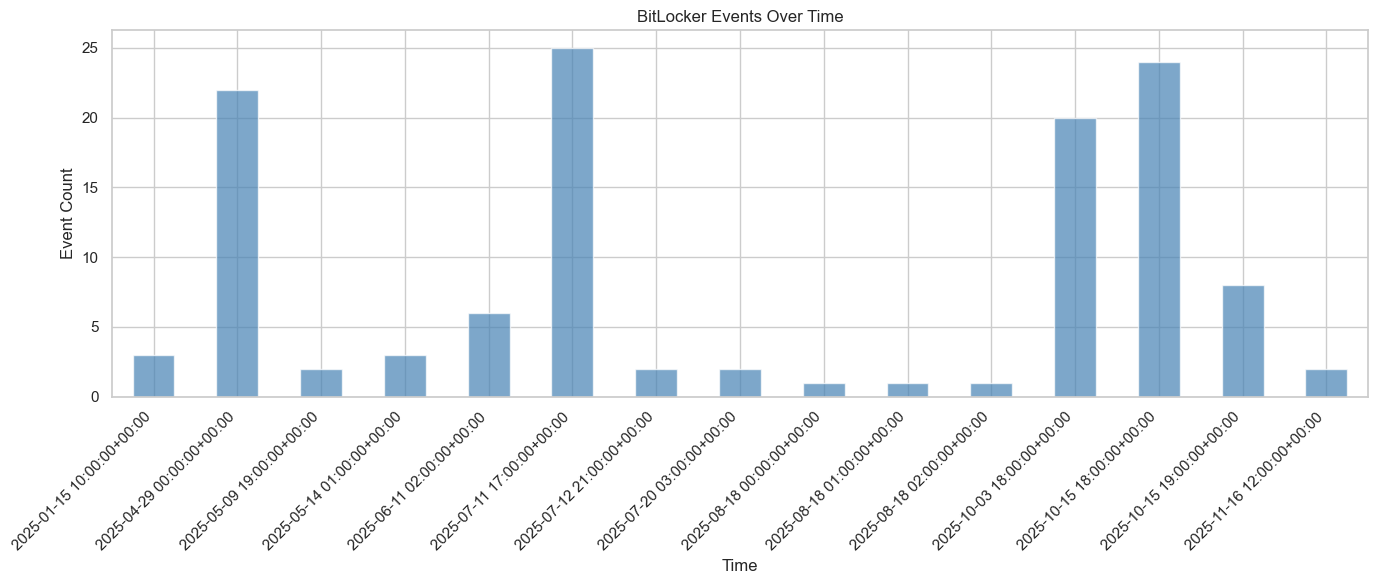

In [11]:
# Visualize event timeline (if matplotlib available)
if HAS_PLOTTING and bitlocker_events_df is not None and 'TimeCreated' in bitlocker_events_df.columns:
    # Filter valid timestamps
    events_with_time = bitlocker_events_df.dropna(subset=['TimeCreated'])
    
    if len(events_with_time) > 0:
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Group by hour and count events
        events_with_time['Hour'] = events_with_time['TimeCreated'].dt.floor('H')
        hourly_counts = events_with_time.groupby('Hour').size()
        
        if len(hourly_counts) > 1:
            hourly_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
            ax.set_xlabel('Time')
            ax.set_ylabel('Event Count')
            ax.set_title('BitLocker Events Over Time')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough time-distributed events for timeline visualization.")
    else:
        print("No events with valid timestamps for visualization.")

## Errors & Warnings

Filter and display error and warning events from the BitLocker event log. These events indicate potential issues that may need attention.

In [12]:
# Known BitLocker event IDs and their descriptions
BITLOCKER_EVENT_DESCRIPTIONS = {
    '779': 'Volume not protected - BitLocker not enabled on volume',
    '792': 'Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS',
    '793': 'Recovery key backup pending - Backup scheduled but not yet completed',
    '812': 'SecureBoot variable error - Could not read SecureBoot UEFI variable',
    '868': 'Network error during key escrow - Connection issue backing up recovery key',
    '875': 'HTTP error during key escrow - Server error backing up recovery key',
}

def get_level_name(level: str) -> str:
    """Convert numeric event level to human-readable name."""
    level_map = {'1': 'Critical', '2': 'Error', '3': 'Warning', '4': 'Information', '5': 'Verbose'}
    return level_map.get(str(level), str(level))

def filter_errors_warnings(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    """Filter DataFrame to only include errors and warnings (Level <= 3)."""
    if df is None or 'Level' not in df.columns:
        return None
    
    # Convert Level to numeric for comparison
    df_copy = df.copy()
    df_copy['LevelNum'] = pd.to_numeric(df_copy['Level'], errors='coerce')
    
    # Filter for Critical (1), Error (2), Warning (3)
    errors_warnings = df_copy[df_copy['LevelNum'] <= 3].copy()
    
    if len(errors_warnings) == 0:
        return None
    
    # Add human-readable level name
    errors_warnings['Severity'] = errors_warnings['Level'].apply(get_level_name)
    
    # Add event description if known
    errors_warnings['Description'] = errors_warnings['EventID'].apply(
        lambda x: BITLOCKER_EVENT_DESCRIPTIONS.get(str(x), '')
    )
    
    return errors_warnings

# Filter BitLocker events for errors and warnings
bitlocker_errors_df = filter_errors_warnings(bitlocker_events_df)

In [13]:
# Display errors and warnings summary
if bitlocker_errors_df is not None and len(bitlocker_errors_df) > 0:
    error_count = len(bitlocker_errors_df[bitlocker_errors_df['Severity'] == 'Error'])
    warning_count = len(bitlocker_errors_df[bitlocker_errors_df['Severity'] == 'Warning'])
    critical_count = len(bitlocker_errors_df[bitlocker_errors_df['Severity'] == 'Critical'])
    
    print("=" * 60)
    print("ERRORS & WARNINGS SUMMARY")
    print("=" * 60)
    
    if critical_count > 0:
        print(f"[CRITICAL] {critical_count} critical event(s)")
    if error_count > 0:
        print(f"[ERROR] {error_count} error event(s)")
    if warning_count > 0:
        print(f"[WARNING] {warning_count} warning event(s)")
    
    print(f"\nTotal: {len(bitlocker_errors_df)} issue(s) found in BitLocker event log")
    
    # Show counts by Event ID with descriptions
    print("\n" + "-" * 60)
    print("Event ID Breakdown:")
    print("-" * 60)
    
    event_summary = bitlocker_errors_df.groupby(['EventID', 'Severity']).agg({
        'TimeCreated': ['count', 'max']
    }).reset_index()
    event_summary.columns = ['EventID', 'Severity', 'Count', 'LastOccurrence']
    event_summary['Description'] = event_summary['EventID'].apply(
        lambda x: BITLOCKER_EVENT_DESCRIPTIONS.get(str(x), 'Unknown event')
    )
    event_summary = event_summary.sort_values(['Severity', 'Count'], ascending=[True, False])
    
    display(event_summary[['EventID', 'Severity', 'Count', 'LastOccurrence', 'Description']])
    
else:
    print("=" * 60)
    print("ERRORS & WARNINGS SUMMARY")
    print("=" * 60)
    print("\n[OK] No errors or warnings found in BitLocker event log.")

ERRORS & WARNINGS SUMMARY
[ERROR] 27 error event(s)
[WARNING] 35 warning event(s)

Total: 62 issue(s) found in BitLocker event log

------------------------------------------------------------
Event ID Breakdown:
------------------------------------------------------------


,EventID,Severity,Count,LastOccurrence,Description
1,792,Error,25,2025-10-15 18:54:07.143032+00:00,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS
5,875,Error,2,2025-11-16 12:25:57.059944+00:00,HTTP error during key escrow - Server error backing up recovery key
2,793,Warning,28,2025-10-15 19:00:15.068186+00:00,Recovery key backup pending - Backup scheduled but not yet completed
0,779,Warning,3,2025-08-18 02:00:55.065367+00:00,Volume not protected - BitLocker not enabled on volume
3,812,Warning,2,2025-07-12 21:31:19.736485+00:00,SecureBoot variable error - Could not read SecureBoot UEFI variable
4,868,Warning,2,2025-11-16 12:25:57.059954+00:00,Network error during key escrow - Connection issue backing up recovery key


In [14]:
# Display recent errors (most severe first)
if bitlocker_errors_df is not None and len(bitlocker_errors_df) > 0:
    print("\n" + "-" * 60)
    print("Recent Errors & Warnings (Last 15):")
    print("-" * 60)
    
    # Sort by severity (errors first) then by time (most recent first)
    severity_order = {'Critical': 0, 'Error': 1, 'Warning': 2}
    sorted_errors = bitlocker_errors_df.copy()
    sorted_errors['SeverityOrder'] = sorted_errors['Severity'].map(severity_order)
    sorted_errors = sorted_errors.sort_values(['SeverityOrder', 'TimeCreated'], ascending=[True, False])
    
    # Display key columns
    display_cols = ['TimeCreated', 'Severity', 'EventID', 'Description', 'Message']
    available_cols = [c for c in display_cols if c in sorted_errors.columns]
    
    display(sorted_errors[available_cols].head(15))


------------------------------------------------------------
Recent Errors & Warnings (Last 15):
------------------------------------------------------------


,TimeCreated,Severity,EventID,Description,Message
120,2025-11-16 12:25:57.059944+00:00,Error,875,HTTP error during key escrow - Server error backing up recovery key,ErrorCode=-2145845248; HttpStatusCode=0; RetryRequest=False; DidSetRetryHint=False; RetryHint=0
107,2025-10-15 18:54:07.143032+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
105,2025-10-15 18:54:07.081430+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
101,2025-10-15 18:54:07.022324+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
97,2025-10-15 18:53:38.076864+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
93,2025-10-15 18:53:38.010904+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
89,2025-10-15 18:53:37.948561+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
87,2025-10-03 18:51:34.129824+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
85,2025-10-03 18:51:34.042273+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287
81,2025-10-03 18:51:33.955994+00:00,Error,792,Recovery key backup failed - Could not back up recovery key to Azure AD/AD DS,IdentificationGUID={485e8349-8ea8-4e35-8227-d07d7a2a52eb}; VolumeName=\\?\Volume{05ef4780-6793-47e3-b594-7ddd570ea4af}; VolumeMountPoint=C:; ErrorCode=-2144272287


## Summary

Consolidated findings from all data sources.

In [15]:
def generate_summary():
    """
    Generate a consolidated summary of all parsed data.
    """
    summary = {
        'Data Source': [],
        'Status': [],
        'Details': []
    }
    
    # BitLocker Volume Status
    if bitlocker_df is not None:
        vol_count = len(bitlocker_df)
        status = 'OK' if vol_count > 0 else 'Warning'
        details = f"{vol_count} volume(s) found"
        
        # Check protection status if available
        if 'ProtectionStatus' in bitlocker_df.columns:
            protected = bitlocker_df['ProtectionStatus'].str.contains('On', case=False, na=False).sum()
            details += f", {protected} protected"
    else:
        status = 'Missing'
        details = 'Get-BitLockerVolume.txt not found'
    
    summary['Data Source'].append('BitLocker Volumes')
    summary['Status'].append(status)
    summary['Details'].append(details)
    
    # MDM Policy
    if mdm_df is not None:
        policy_count = len(mdm_df)
        summary['Data Source'].append('MDM Policies')
        summary['Status'].append('OK')
        summary['Details'].append(f"{policy_count} BitLocker policy setting(s) found")
    else:
        summary['Data Source'].append('MDM Policies')
        summary['Status'].append('N/A')
        summary['Details'].append('No MDM data (requires -MDM flag during collection)')
    
    # BitLocker Events
    if bitlocker_events_df is not None:
        event_count = len(bitlocker_events_df)
        summary['Data Source'].append('BitLocker Events')
        summary['Status'].append('OK')
        summary['Details'].append(f"{event_count} event(s) in log")
    else:
        summary['Data Source'].append('BitLocker Events')
        summary['Status'].append('Missing')
        summary['Details'].append('Event log file not found')
    
    # Errors & Warnings - NEW
    if bitlocker_errors_df is not None and len(bitlocker_errors_df) > 0:
        error_count = len(bitlocker_errors_df[bitlocker_errors_df['Severity'] == 'Error'])
        warning_count = len(bitlocker_errors_df[bitlocker_errors_df['Severity'] == 'Warning'])
        critical_count = len(bitlocker_errors_df[bitlocker_errors_df['Severity'] == 'Critical'])
        
        # Determine status based on severity
        if critical_count > 0:
            status = 'CRITICAL'
        elif error_count > 0:
            status = 'ERROR'
        else:
            status = 'WARNING'
        
        parts = []
        if critical_count > 0:
            parts.append(f"{critical_count} critical")
        if error_count > 0:
            parts.append(f"{error_count} error(s)")
        if warning_count > 0:
            parts.append(f"{warning_count} warning(s)")
        details = ', '.join(parts)
        
        summary['Data Source'].append('Errors & Warnings')
        summary['Status'].append(status)
        summary['Details'].append(details)
    else:
        summary['Data Source'].append('Errors & Warnings')
        summary['Status'].append('OK')
        summary['Details'].append('No errors or warnings found')
    
    # System Events
    if system_events_df is not None:
        event_count = len(system_events_df)
        summary['Data Source'].append('System Events')
        summary['Status'].append('OK')
        summary['Details'].append(f"{event_count} event(s) parsed")
    else:
        summary['Data Source'].append('System Events')
        summary['Status'].append('Missing')
        summary['Details'].append('System event log not found')
    
    return pd.DataFrame(summary)

In [16]:
print("\n" + "=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nData Directory: {DATA_DIR.resolve()}")
print(f"Analysis Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

summary_df = generate_summary()
display(summary_df)

# Status indicators
missing_count = (summary_df['Status'] == 'Missing').sum()
error_count = (summary_df['Status'] == 'ERROR').sum()
critical_count = (summary_df['Status'] == 'CRITICAL').sum()
warning_count = (summary_df['Status'] == 'WARNING').sum()

print()
if critical_count > 0:
    print("[!!!] CRITICAL issues detected - immediate attention required!")
elif error_count > 0:
    print("[!!] ERRORS detected - review Errors & Warnings section above for details.")
elif warning_count > 0:
    print("[!] WARNINGS detected - review Errors & Warnings section above for details.")

if missing_count > 0:
    print(f"[!] {missing_count} data source(s) missing - some analyses may be incomplete.")
elif critical_count == 0 and error_count == 0 and warning_count == 0:
    print("[OK] All data sources present with no errors or warnings.")


ANALYSIS SUMMARY

Data Directory: C:\Temp\tsscat\Get-BitLockerStatus\ExampleData
Analysis Time: 2025-12-20 15:14:28



,Data Source,Status,Details
0,BitLocker Volumes,OK,"1 volume(s) found, 1 protected"
1,MDM Policies,OK,124 BitLocker policy setting(s) found
2,BitLocker Events,OK,122 event(s) in log
3,Errors & Warnings,ERROR,"27 error(s), 35 warning(s)"
4,System Events,OK,500 event(s) parsed



[!!] ERRORS detected - review Errors & Warnings section above for details.


---

## Next Steps

Based on the analysis above, consider:

1. **If BitLocker is not enabled**: Review MDM policies and Group Policy settings (FVE_Policies.reg)
2. **If encryption failed**: Check event logs for error codes and TPM status (Get-TPM.txt)
3. **For key escrow issues**: Verify MDM enrollment status and Azure AD connectivity
4. **For recovery scenarios**: Document the recovery key protectors shown in BitLocker volume output

For additional analysis, you can modify the cells above or add new cells to explore specific aspects of the collected data.